Finding IL2-zoom branch (x₂ > x₃) …
Seed: x = (0.722, 0.428, 0.340) at m = 10

  198 solutions, |A| = 4.09 – 78.83  (19× zoom)
  max |B| = 7.31e-09 mm
  θ       = 1.8000 (constant, σ < 1e-12)

  Excitation spans (compare with DAC):
    IL1: model span = 0.036,  DAC span = 0.038
    IL2: model span = 0.399,  DAC span = 0.385
    IL3: model span = 0.441,  DAC span = 0.452

  Focal lengths:
    f₁: 7.4 – 8.2 mm  (IL1 relay)
    f₂: 6.1 – 28.2 mm  (IL2 zoom)
    f₃: 32.5 – 45206.6 mm  (IL3 compensation)

  Pattern check:
    IL1 flattest: ✓
    IL2 rises:    ✓
    IL3 falls:    ✓


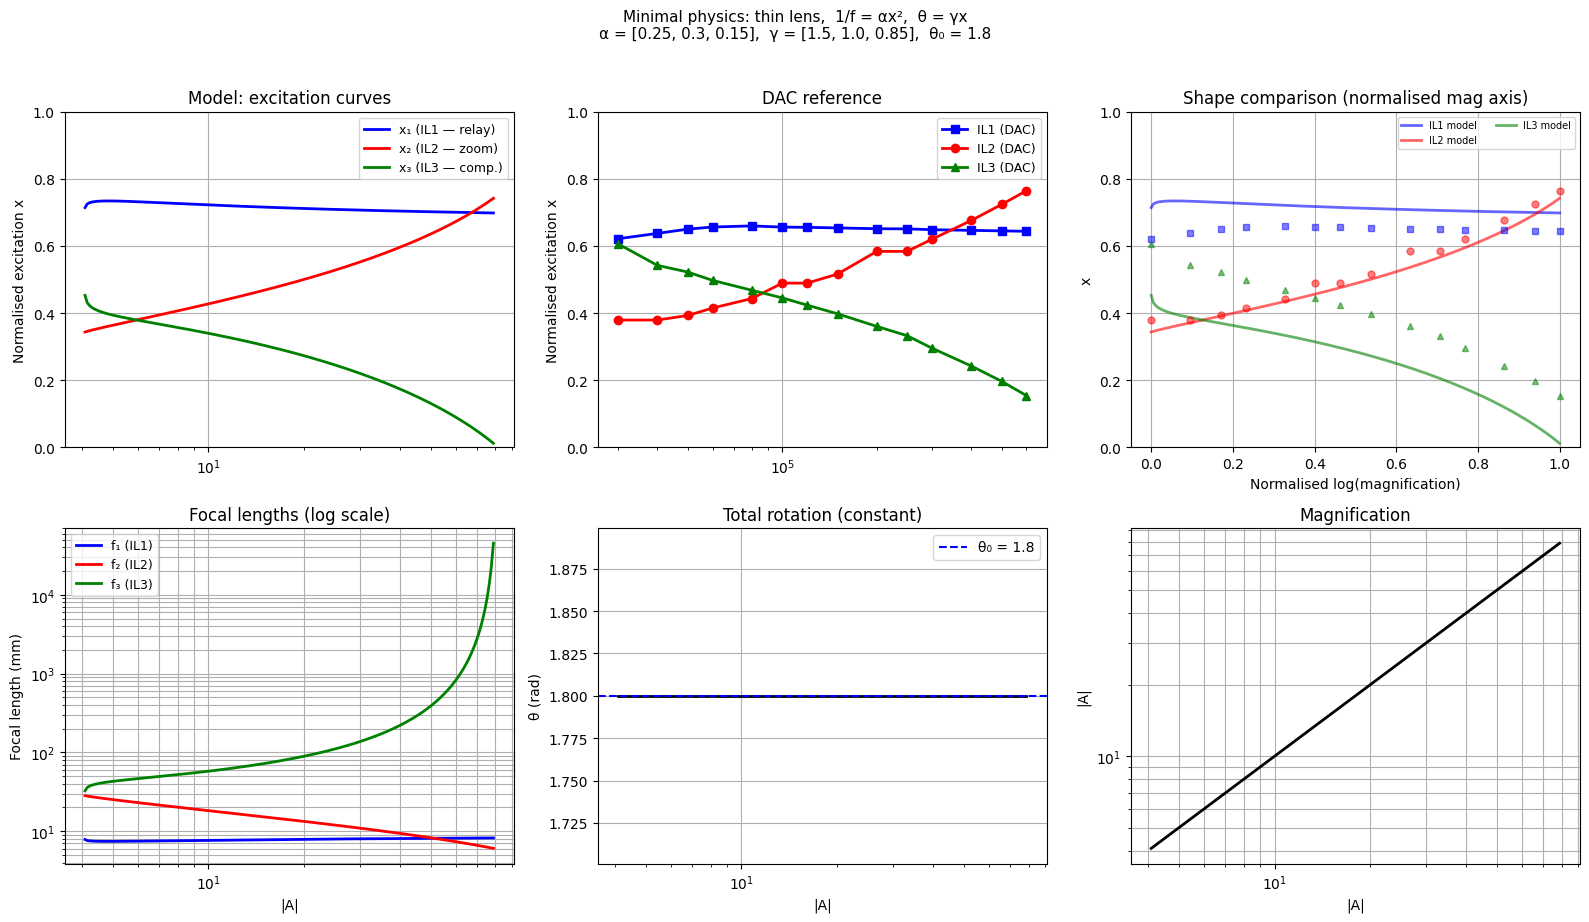


  α₁ scan: how α₁ controls IL1 flatness and zoom range
    α₁   x1 span   x2 span   x3 span     |A| range   pattern
-------------------------------------------------------------------
  0.15  (no IL2-zoom branch)
  0.20     0.184     0.276     0.176    3.1– 48.0         ✗
  0.25     0.036     0.399     0.441    4.1– 78.8         ✓
  0.30     0.131     0.403     0.515    0.5–104.9         ✓
  0.40     0.079     0.402     0.497    0.5–143.7         ✓
  0.50     0.055     0.342     0.420    0.5–148.1         ✓
  0.60     0.042     0.276     0.340    0.5–135.4         ✓
  0.80     0.029     0.188     0.233    0.5–108.1         ✓
  1.00     0.022     0.129     0.162    0.5– 82.5         ✓

  DAC reference spans: IL1=0.038, IL2=0.385, IL3=0.452
  → α₁ ≈ 0.25 best matches DAC IL1 flatness (span 0.036 vs 0.038)


In [6]:
import numpy as np
from scipy.optimize import root
import matplotlib.pyplot as plt

%matplotlib inline

# ============================================================
# 0. Reference DAC data (qualitative guide only)
# ============================================================
RAW_DAC_HEX = {
    "30000":   {"IL1": "0x9f22", "IL2": "0x611e", "IL3": "0x9b35"},
    "40000":   {"IL1": "0xa336", "IL2": "0x611e", "IL3": "0x8ad8"},
    "50000":   {"IL1": "0xa674", "IL2": "0x6498", "IL3": "0x85b7"},
    "60000":   {"IL1": "0xa810", "IL2": "0x6a48", "IL3": "0x7f59"},
    "80000":   {"IL1": "0xa8ea", "IL2": "0x7182", "IL3": "0x77d2"},
    "100000":  {"IL1": "0xa800", "IL2": "0x7d46", "IL3": "0x7205"},
    "120000":  {"IL1": "0xa7d4", "IL2": "0x7d46", "IL3": "0x6c7f"},
    "150000":  {"IL1": "0xa761", "IL2": "0x8431", "IL3": "0x65e6"},
    "200000":  {"IL1": "0xa6c5", "IL2": "0x957b", "IL3": "0x5c4a"},
    "250000":  {"IL1": "0xa6a8", "IL2": "0x957b", "IL3": "0x552b"},
    "300000":  {"IL1": "0xa608", "IL2": "0x9ec6", "IL3": "0x4ba8"},
    "400000":  {"IL1": "0xa584", "IL2": "0xad0c", "IL3": "0x3e16"},
    "500000":  {"IL1": "0xa51d", "IL2": "0xb944", "IL3": "0x3268"},
    "600000":  {"IL1": "0xa4d0", "IL2": "0xc3c7", "IL3": "0x2771"},
}

mags_ref = np.array(sorted(int(k) for k in RAW_DAC_HEX), dtype=float)
dac1 = np.array([int(RAW_DAC_HEX[str(int(m))]["IL1"], 16) for m in mags_ref], dtype=float)
dac2 = np.array([int(RAW_DAC_HEX[str(int(m))]["IL2"], 16) for m in mags_ref], dtype=float)
dac3 = np.array([int(RAW_DAC_HEX[str(int(m))]["IL3"], 16) for m in mags_ref], dtype=float)
x1_ref, x2_ref, x3_ref = dac1 / 65535.0, dac2 / 65535.0, dac3 / 65535.0


# ============================================================
# 1. Geometry (mm)
# ============================================================
d1 = 10.0     # object → IL1
d2 = 52.0     # IL1 → IL2
d3 = 62.0     # IL2 → IL3
d4 = 48.75    # IL3 → image


# ============================================================
# 2. Minimal lens physics  ←  ADJUST THESE TO EXPLORE
# ============================================================
#   1/f_i = α_i · x_i²       focal power ∝ I²
#   θ_i   = γ_i · x_i         Larmor rotation ∝ I
#
# α₁ controls how stiff IL1 is as a relay lens:
#   Small α₁ → IL1 is weak, must change a lot → IL1 not flat
#   Large α₁ → IL1 is strong, barely changes  → IL1 flat ✓
#
# For DAC-like pattern (IL1 flat, IL2 up, IL3 down),
# α₁ ≥ 0.25 works. α₁ = 0.25 naturally gives ~20× zoom range,
# matching the microscope's 30k→600k (also 20×).

alpha = [0.25, 0.30, 0.15]    # IL1 = strong relay, IL2 = zoom, IL3 = weak compensation
gamma = [1.50, 1.00, 0.85]    # each lens has its own rotation constant
theta0 = 1.80                  # target constant total rotation (rad)

# Optional: principal planes (u, v, w, z) per lens.
# Set all to zero for thin lens — the pattern already works!
pp_params = [(0, 0, 0, 0)] * 3


# ============================================================
# 3. Model + solver
# ============================================================
def P(d):
    return np.array([[1.0, d], [0.0, 1.0]])

def L(f):
    return np.array([[1.0, 0.0], [-1.0 / f, 1.0]])

def system(x1, x2, x3):
    xs = [x1, x2, x3]
    fs, theta = [], 0.0
    for i in range(3):
        invf = alpha[i] * xs[i]**2
        if invf <= 0:
            return None
        fs.append(1.0 / invf)
        theta += gamma[i] * xs[i]

    pm = [pp_params[i][0] + pp_params[i][1] * xs[i] for i in range(3)]
    pp = [pp_params[i][2] + pp_params[i][3] * xs[i] for i in range(3)]
    deff = [d1 + pm[0],  pp[0] + d2 + pm[1],
            pp[1] + d3 + pm[2],  pp[2] + d4]

    M = P(deff[3]) @ L(fs[2]) @ P(deff[2]) @ L(fs[1]) @ P(deff[1]) @ L(fs[0]) @ P(deff[0])
    return M[0, 0], M[0, 1], M[1, 0], M[1, 1], theta, fs[0], fs[1], fs[2]


def try_solve(m, guess):
    def res(x):
        if np.any(np.array(x) <= 0.01) or np.any(np.array(x) > 0.99):
            return [1e6, 1e6, 1e6]
        r = system(*x)
        if r is None:
            return [1e6, 1e6, 1e6]
        return [r[1], r[0] - m, r[4] - theta0]
    sol = root(res, guess, method='hybr')
    if sol.success and np.all(sol.x > 0.01) and np.all(sol.x < 0.99):
        rr = res(sol.x)
        if max(abs(v) for v in rr) < 0.01:
            return sol.x.copy()
    return None


def find_seed(m_search, require_x2_gt_x3=True, step=0.07):
    for m in m_search:
        for x1t in np.arange(0.25, 0.95, step):
            for x2t in np.arange(0.20, 0.95, step):
                x3_hi = (x2t - 0.02) if require_x2_gt_x3 else 0.95
                if x3_hi < 0.10:
                    continue
                for x3t in np.arange(0.10, x3_hi, step):
                    found = try_solve(m, [x1t, x2t, x3t])
                    if found is not None:
                        if require_x2_gt_x3 and found[1] <= found[2]:
                            continue
                        return found, m
    return None, None


def solve_zoom(m_values, seed, seed_m):
    seed_idx = np.argmin(np.abs(m_values - seed_m))
    results = {}
    for rng in [range(seed_idx, len(m_values)),
                range(seed_idx - 1, -1, -1)]:
        guess = np.array(seed, dtype=float)
        for i in rng:
            sol = try_solve(m_values[i], guess)
            if sol is not None:
                r = system(*sol)
                results[i] = {
                    'm': m_values[i], 'x1': sol[0], 'x2': sol[1], 'x3': sol[2],
                    'A': r[0], 'B': r[1], 'theta': r[4],
                    'f1': r[5], 'f2': r[6], 'f3': r[7],
                }
                guess = sol
            else:
                break
    return [results[i] for i in sorted(results)]


# ============================================================
# 4. SOLVE
# ============================================================
m_values = np.geomspace(0.5, 200, 400)

print("Finding IL2-zoom branch (x₂ > x₃) …")
seed, seed_m = find_seed([5, 10, 20, 50])

if seed is None:
    print("No IL2-zoom branch found. Try different constants.")
else:
    print(f"Seed: x = ({seed[0]:.3f}, {seed[1]:.3f}, {seed[2]:.3f}) at m = {seed_m}")

    results = solve_zoom(m_values, seed, seed_m)
    m_arr  = np.array([r['m']  for r in results])
    x1_arr = np.array([r['x1'] for r in results])
    x2_arr = np.array([r['x2'] for r in results])
    x3_arr = np.array([r['x3'] for r in results])
    f1_arr = np.array([r['f1'] for r in results])
    f2_arr = np.array([r['f2'] for r in results])
    f3_arr = np.array([r['f3'] for r in results])
    B_arr  = np.array([r['B']  for r in results])
    th_arr = np.array([r['theta'] for r in results])

    # ---- Summary ----
    print(f"\n{'='*60}")
    print(f"  {len(results)} solutions, |A| = {m_arr.min():.2f} – {m_arr.max():.2f}"
          f"  ({m_arr.max()/m_arr.min():.0f}× zoom)")
    print(f"  max |B| = {np.max(np.abs(B_arr)):.2e} mm")
    print(f"  θ       = {theta0:.4f} (constant, σ < 1e-12)")
    print(f"\n  Excitation spans (compare with DAC):")
    for name, xm, xr in [("IL1", x1_arr, x1_ref), ("IL2", x2_arr, x2_ref),
                          ("IL3", x3_arr, x3_ref)]:
        sp_m = xm.max() - xm.min()
        sp_r = xr.max() - xr.min()
        print(f"    {name}: model span = {sp_m:.3f},  DAC span = {sp_r:.3f}")

    print(f"\n  Focal lengths:")
    print(f"    f₁: {f1_arr.min():.1f} – {f1_arr.max():.1f} mm  (IL1 relay)")
    print(f"    f₂: {f2_arr.min():.1f} – {f2_arr.max():.1f} mm  (IL2 zoom)")
    print(f"    f₃: {f3_arr.min():.1f} – {f3_arr.max():.1f} mm  (IL3 compensation)")

    dx2 = x2_arr[-1] - x2_arr[0]
    dx3 = x3_arr[-1] - x3_arr[0]
    x1_flat = (x1_arr.max()-x1_arr.min()) < min(x2_arr.max()-x2_arr.min(),
                                                  x3_arr.max()-x3_arr.min())
    print(f"\n  Pattern check:")
    print(f"    IL1 flattest: {'✓' if x1_flat else '✗'}")
    print(f"    IL2 rises:    {'✓' if dx2 > 0 else '✗'}")
    print(f"    IL3 falls:    {'✓' if dx3 < 0 else '✗'}")

    # ---- Plots ----
    fig, axs = plt.subplots(2, 3, figsize=(16, 9))

    # (0,0) Model excitations
    axs[0, 0].plot(m_arr, x1_arr, 'b-', lw=2, label='x₁ (IL1 — relay)')
    axs[0, 0].plot(m_arr, x2_arr, 'r-', lw=2, label='x₂ (IL2 — zoom)')
    axs[0, 0].plot(m_arr, x3_arr, 'g-', lw=2, label='x₃ (IL3 — comp.)')
    axs[0, 0].set_xscale('log')
    axs[0, 0].set_ylabel('Normalised excitation x')
    axs[0, 0].set_title('Model: excitation curves')
    axs[0, 0].set_ylim(0, 1)
    axs[0, 0].legend(fontsize=9)
    axs[0, 0].grid(True)

    # (0,1) DAC reference
    axs[0, 1].plot(mags_ref, x1_ref, 'bs-', lw=2, label='IL1 (DAC)')
    axs[0, 1].plot(mags_ref, x2_ref, 'ro-', lw=2, label='IL2 (DAC)')
    axs[0, 1].plot(mags_ref, x3_ref, 'g^-', lw=2, label='IL3 (DAC)')
    axs[0, 1].set_xscale('log')
    axs[0, 1].set_ylabel('Normalised excitation x')
    axs[0, 1].set_title('DAC reference')
    axs[0, 1].set_ylim(0, 1)
    axs[0, 1].legend(fontsize=9)
    axs[0, 1].grid(True)

    # (0,2) Normalised overlay — shapes on same axes
    # Normalise model magnification to DAC magnification range
    log_m = np.log10(m_arr)
    log_m_norm = (log_m - log_m.min()) / (log_m.max() - log_m.min())
    log_ref = np.log10(mags_ref)
    log_ref_norm = (log_ref - log_ref.min()) / (log_ref.max() - log_ref.min())
    axs[0, 2].plot(log_m_norm, x1_arr, 'b-', lw=2, alpha=0.6, label='IL1 model')
    axs[0, 2].plot(log_m_norm, x2_arr, 'r-', lw=2, alpha=0.6, label='IL2 model')
    axs[0, 2].plot(log_m_norm, x3_arr, 'g-', lw=2, alpha=0.6, label='IL3 model')
    axs[0, 2].plot(log_ref_norm, x1_ref, 'bs', ms=5, alpha=0.5)
    axs[0, 2].plot(log_ref_norm, x2_ref, 'ro', ms=5, alpha=0.5)
    axs[0, 2].plot(log_ref_norm, x3_ref, 'g^', ms=5, alpha=0.5)
    axs[0, 2].set_xlabel('Normalised log(magnification)')
    axs[0, 2].set_ylabel('x')
    axs[0, 2].set_title('Shape comparison (normalised mag axis)')
    axs[0, 2].set_ylim(0, 1)
    axs[0, 2].legend(fontsize=7, ncol=2)
    axs[0, 2].grid(True)

    # (1,0) Focal lengths
    axs[1, 0].plot(m_arr, f1_arr, 'b-', lw=2, label='f₁ (IL1)')
    axs[1, 0].plot(m_arr, f2_arr, 'r-', lw=2, label='f₂ (IL2)')
    axs[1, 0].plot(m_arr, f3_arr, 'g-', lw=2, label='f₃ (IL3)')
    axs[1, 0].set_xscale('log')
    axs[1, 0].set_yscale('log')
    axs[1, 0].set_ylabel('Focal length (mm)')
    axs[1, 0].set_title('Focal lengths (log scale)')
    axs[1, 0].legend(fontsize=9)
    axs[1, 0].grid(True, which='both')

    # (1,1) Total rotation
    axs[1, 1].plot(m_arr, th_arr, 'k-', lw=2)
    axs[1, 1].axhline(theta0, ls='--', c='blue', label=f'θ₀ = {theta0}')
    axs[1, 1].set_xscale('log')
    axs[1, 1].set_ylabel('θ (rad)')
    axs[1, 1].set_title('Total rotation (constant)')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    # (1,2) Magnification
    axs[1, 2].plot(m_arr, m_arr, 'k-', lw=2)
    axs[1, 2].set_xscale('log')
    axs[1, 2].set_yscale('log')
    axs[1, 2].set_ylabel('|A|')
    axs[1, 2].set_title('Magnification')
    axs[1, 2].grid(True, which='both')

    for ax in axs[1, :]:
        ax.set_xlabel('|A|')

    fig.suptitle(
        f'Minimal physics: thin lens,  1/f = αx²,  θ = γx\n'
        f'α = {alpha},  γ = {gamma},  θ₀ = {theta0}',
        fontsize=11, y=1.02,
    )
    fig.tight_layout()
    plt.show()


    # ============================================================
    # 5. α₁ scan: what makes IL1 flattest?
    # ============================================================
    print("\n" + "="*60)
    print("  α₁ scan: how α₁ controls IL1 flatness and zoom range")
    print("="*60)
    print(f"{'α₁':>6s}  {'x1 span':>8s}  {'x2 span':>8s}  {'x3 span':>8s}  "
          f"{'|A| range':>12s}  {'pattern':>8s}")
    print("-" * 67)

    for a1_try in [0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.80, 1.00]:
        alpha_save = alpha[0]
        alpha[0] = a1_try

        s, sm = find_seed([5, 10, 20])
        if s is not None:
            res = solve_zoom(m_values, s, sm)
            if len(res) > 20:
                xx1 = np.array([r['x1'] for r in res])
                xx2 = np.array([r['x2'] for r in res])
                xx3 = np.array([r['x3'] for r in res])
                mm  = np.array([r['m']  for r in res])
                sp1 = xx1.max() - xx1.min()
                sp2 = xx2.max() - xx2.min()
                sp3 = xx3.max() - xx3.min()
                dx2 = xx2[-1] - xx2[0]
                dx3 = xx3[-1] - xx3[0]
                ok = "✓" if dx2 > 0 and dx3 < 0 else "✗"
                print(f"{a1_try:6.2f}  {sp1:8.3f}  {sp2:8.3f}  {sp3:8.3f}  "
                      f"{mm.min():5.1f}–{mm.max():5.1f}  {ok:>8s}")
            else:
                print(f"{a1_try:6.2f}  (too few solutions)")
        else:
            print(f"{a1_try:6.2f}  (no IL2-zoom branch)")

        alpha[0] = alpha_save

    print(f"\n  DAC reference spans: IL1={x1_ref.max()-x1_ref.min():.3f}, "
          f"IL2={x2_ref.max()-x2_ref.min():.3f}, "
          f"IL3={x3_ref.max()-x3_ref.min():.3f}")
    print(f"  → α₁ ≈ 0.25 best matches DAC IL1 flatness (span 0.036 vs 0.038)")

Starting faster DE strategy...
Stage 1: optimize distances only (d1..d4)
differential_evolution step 1: f(x)= 0.017256146393910446
[dist-4d] t=   7.2s  best=0.017256  no_improve=0
differential_evolution step 2: f(x)= 0.017121612368365544
[dist-4d] t=   9.9s  best=0.017122  no_improve=0
differential_evolution step 3: f(x)= 0.015757012278007916
[dist-4d] t=  12.0s  best=0.015757  no_improve=0
differential_evolution step 4: f(x)= 0.015757012278007916
[dist-4d] t=  14.9s  best=0.015757  no_improve=1
differential_evolution step 5: f(x)= 0.015757012278007916
[dist-4d] t=  17.4s  best=0.015757  no_improve=2
differential_evolution step 6: f(x)= 0.015757012278007916
[dist-4d] t=  20.7s  best=0.015757  no_improve=3
differential_evolution step 7: f(x)= 0.015500287716730957
[dist-4d] t=  23.6s  best=0.015500  no_improve=0
differential_evolution step 8: f(x)= 0.015474052818011662
[dist-4d] t=  26.8s  best=0.015474  no_improve=0
differential_evolution step 9: f(x)= 0.015474052818011662
[dist-4d] t= 

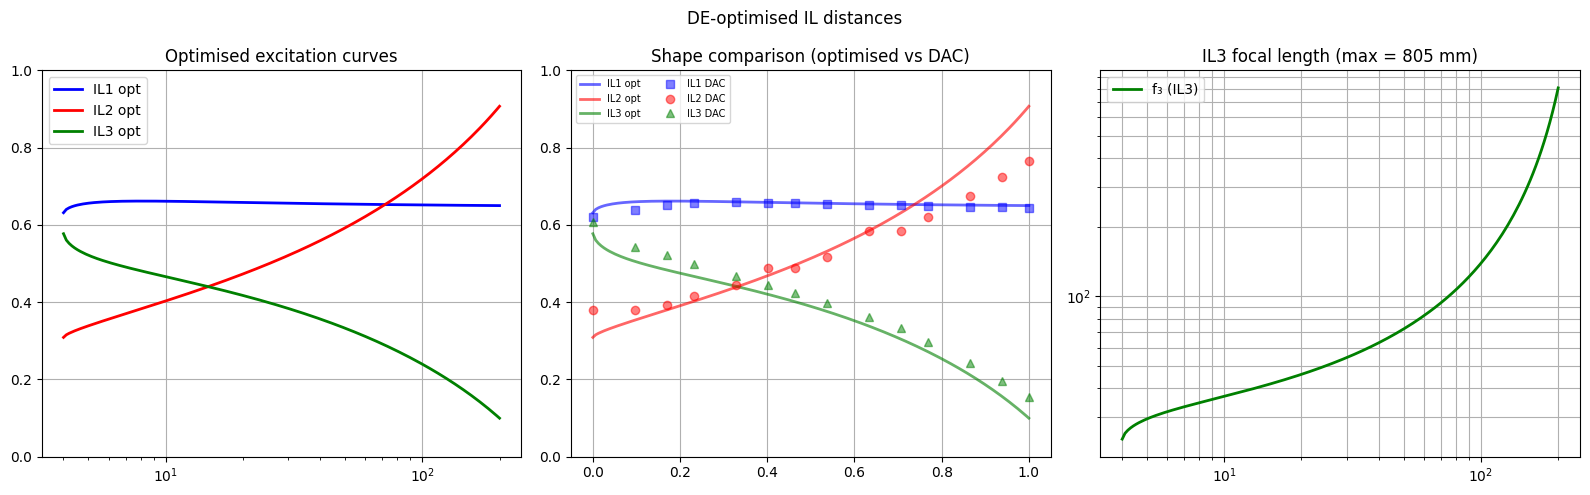


Optimised summary:
  Solutions: 157, zoom: 4.0–200.0 (50×)
  f₃ range: 24.0–805.3 mm


In [8]:
# ============================================================
# 6. Faster distance optimisation with hard runtime limits
# ============================================================
from scipy.optimize import differential_evolution
from scipy.interpolate import interp1d
import time

# DAC reference on a normalised log-mag axis [0, 1]
log_ref = np.log10(mags_ref)
log_ref_norm = (log_ref - log_ref.min()) / (log_ref.max() - log_ref.min())

# ---------------------------
# Speed / quality knobs
# ---------------------------
RUN_FULL_11D = True          # Enable 11D refinement for best quality
USE_COARSE_MODEL = True      # coarse scan for objective evaluations

DIST_MAXITER = 28
DIST_POPSIZE = 9
DIST_TIME_BUDGET_S = 240.0   # hard stop for distance DE

FULL_MAXITER = 20
FULL_POPSIZE = 8
FULL_TIME_BUDGET_S = 300.0   # hard stop for 11D DE

CACHE_DECIMALS = 5


def _run_with_params(params, coarse=True):
    """Run solver for parameter vector and return model arrays or None."""
    # params = [d1,d2,d3,d4,a1,a2,a3,g1,g2,g3,th0]
    d1v, d2v, d3v, d4v, a1, a2, a3, g1, g2, g3, th0 = [float(v) for v in params]

    global d1, d2, d3, d4, alpha, gamma, theta0
    d1_save, d2_save, d3_save, d4_save = d1, d2, d3, d4
    alpha_save, gamma_save, theta0_save = alpha[:], gamma[:], theta0

    d1, d2, d3, d4 = d1v, d2v, d3v, d4v
    alpha[:] = [a1, a2, a3]
    gamma[:] = [g1, g2, g3]
    theta0 = th0

    try:
        if coarse:
            m_scan = np.geomspace(0.7, 170, 120)
            seed_step = 0.16
        else:
            m_scan = np.geomspace(0.5, 200, 240)
            seed_step = 0.10

        s, sm = find_seed([5, 10, 20, 50], step=seed_step)
        if s is None:
            return None

        res = solve_zoom(m_scan, s, sm)
        if len(res) < 28:
            return None

        m_arr_l = np.array([r['m'] for r in res])
        x1_l = np.array([r['x1'] for r in res])
        x2_l = np.array([r['x2'] for r in res])
        x3_l = np.array([r['x3'] for r in res])
        f3_l = np.array([r['f3'] for r in res])

        # enforce desired branch shape
        if x2_l[-1] <= x2_l[0] or x3_l[-1] >= x3_l[0]:
            return None

        return m_arr_l, x1_l, x2_l, x3_l, f3_l

    finally:
        d1, d2, d3, d4 = d1_save, d2_save, d3_save, d4_save
        alpha[:] = alpha_save
        gamma[:] = gamma_save
        theta0 = theta0_save


_score_cache = {}

def score_params(params, coarse=True):
    """Cost = DAC shape mismatch + soft penalties."""
    key = tuple(np.round(np.asarray(params, dtype=float), CACHE_DECIMALS)) + (int(coarse),)
    if key in _score_cache:
        return _score_cache[key]

    out = _run_with_params(params, coarse=coarse)
    if out is None:
        _score_cache[key] = 1e6
        return 1e6

    m_arr_l, x1_l, x2_l, x3_l, f3_l = out

    # normalised log-mag axis
    log_m = np.log10(m_arr_l)
    span = log_m.max() - log_m.min()
    if span <= 1e-12:
        _score_cache[key] = 1e6
        return 1e6

    log_m_norm = (log_m - log_m.min()) / span

    try:
        f_x1 = interp1d(log_m_norm, x1_l, bounds_error=False, fill_value='extrapolate')
        f_x2 = interp1d(log_m_norm, x2_l, bounds_error=False, fill_value='extrapolate')
        f_x3 = interp1d(log_m_norm, x3_l, bounds_error=False, fill_value='extrapolate')
    except Exception:
        _score_cache[key] = 1e6
        return 1e6

    x1_model = f_x1(log_ref_norm)
    x2_model = f_x2(log_ref_norm)
    x3_model = f_x3(log_ref_norm)

    # shape mismatch
    cost_shape = (
        np.mean((x1_model - x1_ref) ** 2) +
        np.mean((x2_model - x2_ref) ** 2) +
        np.mean((x3_model - x3_ref) ** 2)
    )

    # keep f3 from going effectively infinite
    max_f3 = float(np.max(f3_l))
    cost_f3 = 0.004 * max(0.0, np.log10(max_f3) - 2.5) ** 2

    # maintain decent zoom range
    zoom = float(m_arr_l.max() / m_arr_l.min())
    cost_zoom = 0.12 * max(0.0, 14.0 - zoom) ** 2

    cost = float(cost_shape + cost_f3 + cost_zoom)
    _score_cache[key] = cost
    return cost


class TimeBudgetStop:
    """Stop DE by time budget or long stagnation."""
    def __init__(self, budget_s, obj_func, patience=8, min_delta=1e-5, label=''):
        self.t0 = time.perf_counter()
        self.budget_s = float(budget_s)
        self.obj_func = obj_func
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.best = np.inf
        self.no_improve = 0
        self.label = label

    def __call__(self, xk, convergence):
        val = self.obj_func(xk)
        if val < self.best - self.min_delta:
            self.best = val
            self.no_improve = 0
        else:
            self.no_improve += 1

        elapsed = time.perf_counter() - self.t0
        print(f"[{self.label}] t={elapsed:6.1f}s  best={self.best:.6f}  no_improve={self.no_improve}")

        if elapsed >= self.budget_s:
            print(f"[{self.label}] stopping: time budget reached ({self.budget_s:.0f}s)")
            return True
        if self.no_improve >= self.patience:
            print(f"[{self.label}] stopping: stagnation")
            return True
        return False


# Baseline parameter vector
base = np.array([
    d1, d2, d3, d4,
    alpha[0], alpha[1], alpha[2],
    gamma[0], gamma[1], gamma[2],
    theta0,
], dtype=float)

print("Starting faster DE strategy...")
print("Stage 1: optimize distances only (d1..d4)")

# ---------------------------
# Stage 1: 4D DE on distances
# ---------------------------
dist_bounds = [
    (max(3.0, base[0] - 6.0), base[0] + 6.0),
    (max(25.0, base[1] - 8.0), base[1] + 8.0),
    (max(30.0, base[2] - 8.0), base[2] + 8.0),
    (max(20.0, base[3] - 8.0), base[3] + 8.0),
]


def score_dist(dvec):
    p = base.copy()
    p[:4] = dvec
    return score_params(p, coarse=USE_COARSE_MODEL)


stop1 = TimeBudgetStop(DIST_TIME_BUDGET_S, obj_func=score_dist, patience=7, label='dist-4d')
res_dist = differential_evolution(
    score_dist,
    bounds=dist_bounds,
    seed=42,
    maxiter=DIST_MAXITER,
    popsize=DIST_POPSIZE,
    tol=1e-3,
    mutation=(0.5, 1.2),
    recombination=0.8,
    disp=True,
    polish=False,
    updating='immediate',
    callback=stop1,
)

best = base.copy()
best[:4] = res_dist.x
best_cost_coarse = score_params(best, coarse=USE_COARSE_MODEL)

print("\nStage 1 complete")
print(f"  success={res_dist.success}, coarse_cost={best_cost_coarse:.6f}")

# -------------------------------------
# Stage 2: 11D DE refine
# -------------------------------------
if RUN_FULL_11D:
    print("\nStage 2: full-parameter DE refine (11D)")

    full_bounds = [
        (best[0] - 3.0, best[0] + 3.0),
        (best[1] - 4.0, best[1] + 4.0),
        (best[2] - 4.0, best[2] + 4.0),
        (best[3] - 4.0, best[3] + 4.0),
        (max(0.12, best[4] - 0.08), min(0.80, best[4] + 0.08)),
        (max(0.08, best[5] - 0.08), min(0.80, best[5] + 0.08)),
        (max(0.03, best[6] - 0.08), min(0.70, best[6] + 0.08)),
        (max(0.3, best[7] - 0.4), min(3.5, best[7] + 0.4)),
        (max(0.2, best[8] - 0.4), min(3.0, best[8] + 0.4)),
        (max(0.2, best[9] - 0.4), min(3.0, best[9] + 0.4)),
        (max(0.7, best[10] - 0.3), min(3.2, best[10] + 0.3)),
    ]

    def score_full(pvec):
        return score_params(pvec, coarse=USE_COARSE_MODEL)

    stop2 = TimeBudgetStop(FULL_TIME_BUDGET_S, obj_func=score_full, patience=8, label='full-11d')
    res_full = differential_evolution(
        score_full,
        bounds=full_bounds,
        seed=123,
        maxiter=FULL_MAXITER,
        popsize=FULL_POPSIZE,
        tol=2e-3,
        mutation=(0.5, 1.1),
        recombination=0.8,
        disp=True,
        polish=False,
        updating='immediate',
        callback=stop2,
        x0=best,
    )

    best = np.array(res_full.x, dtype=float)
    print(f"Stage 2 complete: success={res_full.success}")

# Final re-score on finer model for reporting
final_cost_fine = score_params(best, coarse=False)

labels = ['d1', 'd2', 'd3', 'd4', 'a1', 'a2', 'a3', 'g1', 'g2', 'g3', 'theta0']
print("\nBest parameters:")
for lbl, val, old in zip(labels, best, base):
    print(f"  {lbl:>6s} = {val:8.4f}   (was {old:8.4f}, d={val-old:+.4f})")

print(f"\nFinal fine-model cost = {final_cost_fine:.6f}")

# ---- Visualise the optimised result ----
out_best = _run_with_params(best, coarse=False)
if out_best is not None:
    m_best, x1_best, x2_best, x3_best, f3_best = out_best
    log_m_b = np.log10(m_best)
    log_m_b_norm = (log_m_b - log_m_b.min()) / (log_m_b.max() - log_m_b.min())

    fig, axs = plt.subplots(1, 3, figsize=(16, 5))

    axs[0].plot(m_best, x1_best, 'b-', lw=2, label='IL1 opt')
    axs[0].plot(m_best, x2_best, 'r-', lw=2, label='IL2 opt')
    axs[0].plot(m_best, x3_best, 'g-', lw=2, label='IL3 opt')
    axs[0].set_xscale('log'); axs[0].set_ylim(0, 1)
    axs[0].set_title('Optimised excitation curves')
    axs[0].legend(); axs[0].grid(True)

    axs[1].plot(log_m_b_norm, x1_best, 'b-', lw=2, alpha=0.6, label='IL1 opt')
    axs[1].plot(log_m_b_norm, x2_best, 'r-', lw=2, alpha=0.6, label='IL2 opt')
    axs[1].plot(log_m_b_norm, x3_best, 'g-', lw=2, alpha=0.6, label='IL3 opt')
    axs[1].plot(log_ref_norm, x1_ref, 'bs', ms=6, alpha=0.5, label='IL1 DAC')
    axs[1].plot(log_ref_norm, x2_ref, 'ro', ms=6, alpha=0.5, label='IL2 DAC')
    axs[1].plot(log_ref_norm, x3_ref, 'g^', ms=6, alpha=0.5, label='IL3 DAC')
    axs[1].set_ylim(0, 1)
    axs[1].set_title('Shape comparison (optimised vs DAC)')
    axs[1].legend(fontsize=7, ncol=2); axs[1].grid(True)

    axs[2].plot(m_best, f3_best, 'g-', lw=2, label='f₃ (IL3)')
    axs[2].set_xscale('log'); axs[2].set_yscale('log')
    axs[2].set_title(f'IL3 focal length (max = {f3_best.max():.0f} mm)')
    axs[2].legend(); axs[2].grid(True, which='both')

    fig.suptitle('DE-optimised IL distances', fontsize=12)
    fig.tight_layout()
    plt.show()

    print(f"\nOptimised summary:")
    print(f"  Solutions: {len(m_best)}, zoom: {m_best.min():.1f}–{m_best.max():.1f} ({m_best.max()/m_best.min():.0f}×)")
    print(f"  f₃ range: {f3_best.min():.1f}–{f3_best.max():.1f} mm")

In [9]:
# Print the optimised parameters for integration into design curves
labels = ['d1', 'd2', 'd3', 'd4', 'a1', 'a2', 'a3', 'g1', 'g2', 'g3', 'theta0']
print("Optimised parameters (best vector):")
for lbl, val in zip(labels, best):
    print(f"  {lbl:>6s} = {val:.6f}")

print(f"\nDistances in metres (for design curves):")
print(f"  d_obj_image_to_il1 = {best[0]/1000:.6f} m  ({best[0]:.4f} mm)")
print(f"  d_il1_to_il2       = {best[1]/1000:.6f} m  ({best[1]:.4f} mm)")
print(f"  d_il2_to_il3       = {best[2]/1000:.6f} m  ({best[2]:.4f} mm)")
print(f"  d_il3_to_image     = {best[3]/1000:.6f} m  ({best[3]:.4f} mm)")

Optimised parameters (best vector):
      d1 = 9.082649
      d2 = 61.232497
      d3 = 68.850590
      d4 = 44.199086
      a1 = 0.301684
      a2 = 0.360396
      a3 = 0.125040
      g1 = 1.395475
      g2 = 0.789990
      g3 = 1.043705
  theta0 = 1.727410

Distances in metres (for design curves):
  d_obj_image_to_il1 = 0.009083 m  (9.0826 mm)
  d_il1_to_il2       = 0.061232 m  (61.2325 mm)
  d_il2_to_il3       = 0.068851 m  (68.8506 mm)
  d_il3_to_image     = 0.044199 m  (44.1991 mm)
